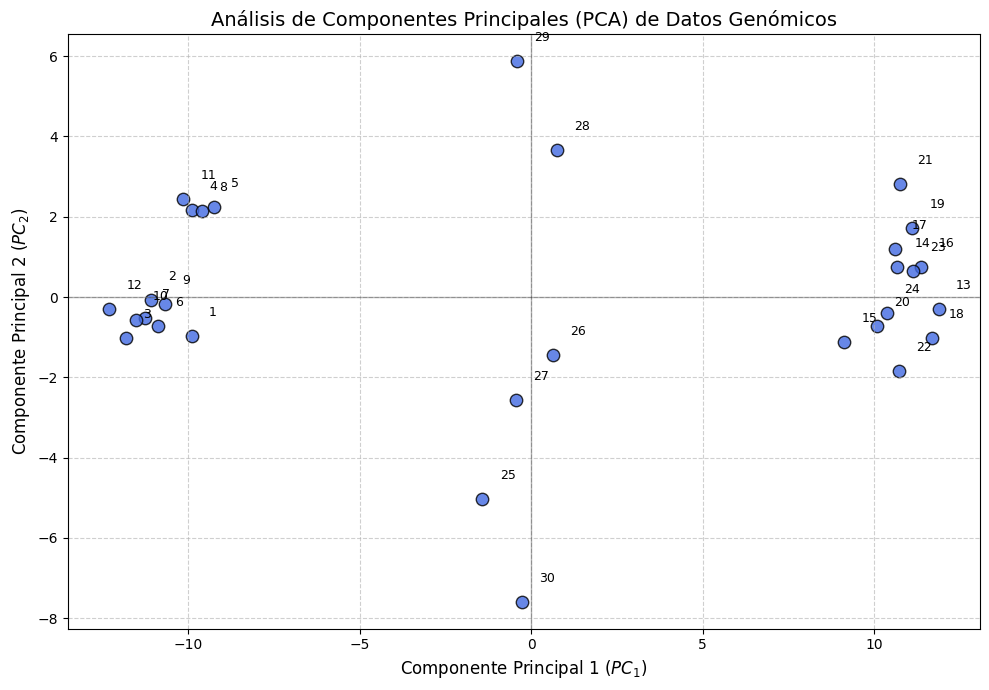

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Lectura del Conjunto de Datos

# Cargamos el archivo omitiendo la primera columna que son los nombres (Individuo_1, etc.)
df = pd.read_csv('datos_genotipo.csv', index_col=0)
G = df.values # Matriz G de tamaño (30, 100)
n, m = G.shape


# 2. Estimación de Frecuencias y Limpieza

# Calculamos la frecuencia del alelo variante p_j para cada columna
p = np.sum(G, axis=0) / (2 * n)

# Filtramos los SNPs constantes para evitar divisiones por cero o singularidades
# Nos quedamos solo con los índices donde la frecuencia es estrictamente mayor a 0 y menor a 1
snps_validos = (p > 0) & (p < 1)

# Aplicamos la máscara a la matriz y al vector de frecuencias
G_filtrada = G[:, snps_validos]
p_filtrada = p[snps_validos]


# 3. Normalización de Patterson (Wright-Fisher)

# Restamos la media esperada y dividimos por la desviación estándar
# numpy maneja las operaciones vectorizadas a lo largo de las columnas automáticamente
G_norm = (G_filtrada - 2 * p_filtrada) / np.sqrt(2 * p_filtrada * (1 - p_filtrada))

# 4. Factorización y Proyección SVD

# Calculamos la SVD de la matriz normalizada

U, S, Vt = np.linalg.svd(G_norm, full_matrices=False)

# Las coordenadas de los Componentes Principales son PC = U * Sigma
# S es un vector 1D con los valores singulares, np.diag(S) lo convierte en matriz diagonal
PC = U @ np.diag(S)

# Extraemos el primer y segundo componente principal
PC1 = PC[:, 0]
PC2 = PC[:, 1]


# 5. Visualización (Gráfico de Dispersión)

plt.figure(figsize=(10, 7))
plt.scatter(PC1, PC2, c='royalblue', edgecolors='k', s=80, alpha=0.8)


for i, txt in enumerate(df.index):

    plt.annotate(txt.split('_')[1], (PC1[i] + 0.5, PC2[i] + 0.5), fontsize=9)

plt.title('Análisis de Componentes Principales (PCA) de Datos Genómicos', fontsize=14)
plt.xlabel('Componente Principal 1 ($PC_1$)', fontsize=12)
plt.ylabel('Componente Principal 2 ($PC_2$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black',linewidth=1, alpha=0.3)
plt.axvline(0, color='black',linewidth=1, alpha=0.3)
plt.tight_layout()

# Guardar la figura para tu informe en LaTeX
plt.savefig('pca_genetica.pdf')
plt.show()